<a href="https://colab.research.google.com/github/mujtaba-mohiyuddin/ucb-traffic-sign-recognition/blob/main/UCB_20260830_Concrete_Strength_Feature_Engineering_Model_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Concrete Compressive Strength — Feature Engineering & Model Tuning

**Practical Application — Post Graduate Certificate in Machine Learning and Artificial Intelligence**

**Goal:** Using the concrete compressive strength dataset, apply feature engineering methods to build a regression model that predicts compressive strength within an 85%-95% accuracy tolerance band, at a 95% confidence level.

**Target variable:** `strength` (concrete compressive strength, MPa)

**Predictors:** `cement`, `slag`, `ash`, `water`, `superplastic`, `coarseagg`, `fineagg`, `age`

This notebook is organized around the four deliverables from the problem statement:
1. Exploratory Data Quality Report (univariate + multivariate analysis)
2. Feature Engineering
3. Model Building & Feature Importance
4. Model Tuning & Performance Evaluation

## Setup — Imports & Load Data

### Upload `concrete.csv`

Please run the cell below and select the `concrete.csv` file from your local machine to upload it to the Colab environment.

In [2]:
from google.colab import files

# Upload the concrete.csv file
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving concrete.csv to concrete (1).csv
User uploaded file "concrete (1).csv" with length 41415 bytes


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance
from sklearn.mixture import GaussianMixture

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

df = pd.read_csv("concrete.csv")
print("Shape:", df.shape)
df.head()

Shape: (1030, 9)


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


---
## Deliverable 1 — Exploratory Data Quality Report

### 1.1 Univariate Analysis
Data types, ranges, central tendency, spread, distribution shape, missing values, and outliers for each attribute.

In [4]:
print("Data types:\n")
print(df.dtypes)
print("\nMissing values per column:\n")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Data types:

cement          float64
slag            float64
ash             float64
water           float64
superplastic    float64
coarseagg       float64
fineagg         float64
age               int64
strength        float64
dtype: object

Missing values per column:

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64

Duplicate rows: 25


In [5]:
# Descriptive statistics: central values, spread, and quartiles
desc = df.describe().T
desc["skewness"] = df.skew()
desc["kurtosis"] = df.kurt()
desc

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
cement,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0,0.509481,-0.520652
slag,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4,0.800717,-0.508175
ash,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1,0.537354,-1.328746
water,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0,0.074628,0.122082
superplastic,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2,0.907203,1.411269
coarseagg,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0,-0.040220,-0.599016
fineagg,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6,-0.253010,-0.102177
age,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0,3.269177,12.168989
strength,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6,0.416977,-0.313725


Interpretation notes to fill in as you review the table above: which attributes are right/left-skewed (skewness far from 0), which have heavy tails (high kurtosis), and how spread compares to the mean (coefficient of variation = std/mean).

In [6]:
# Coefficient of variation - relative spread, useful for comparing variability across differently-scaled features
cv = (df.std() / df.mean()).sort_values(ascending=False)
print("Coefficient of Variation (std/mean) by feature:")
print(cv)

Coefficient of Variation (std/mean) by feature:
age             1.383420
ash             1.181010
slag            1.167581
superplastic    0.962799
strength        0.466407
cement          0.371687
water           0.117610
fineagg         0.103643
coarseagg       0.079918
dtype: float64


### Distribution shape — histograms with density curves

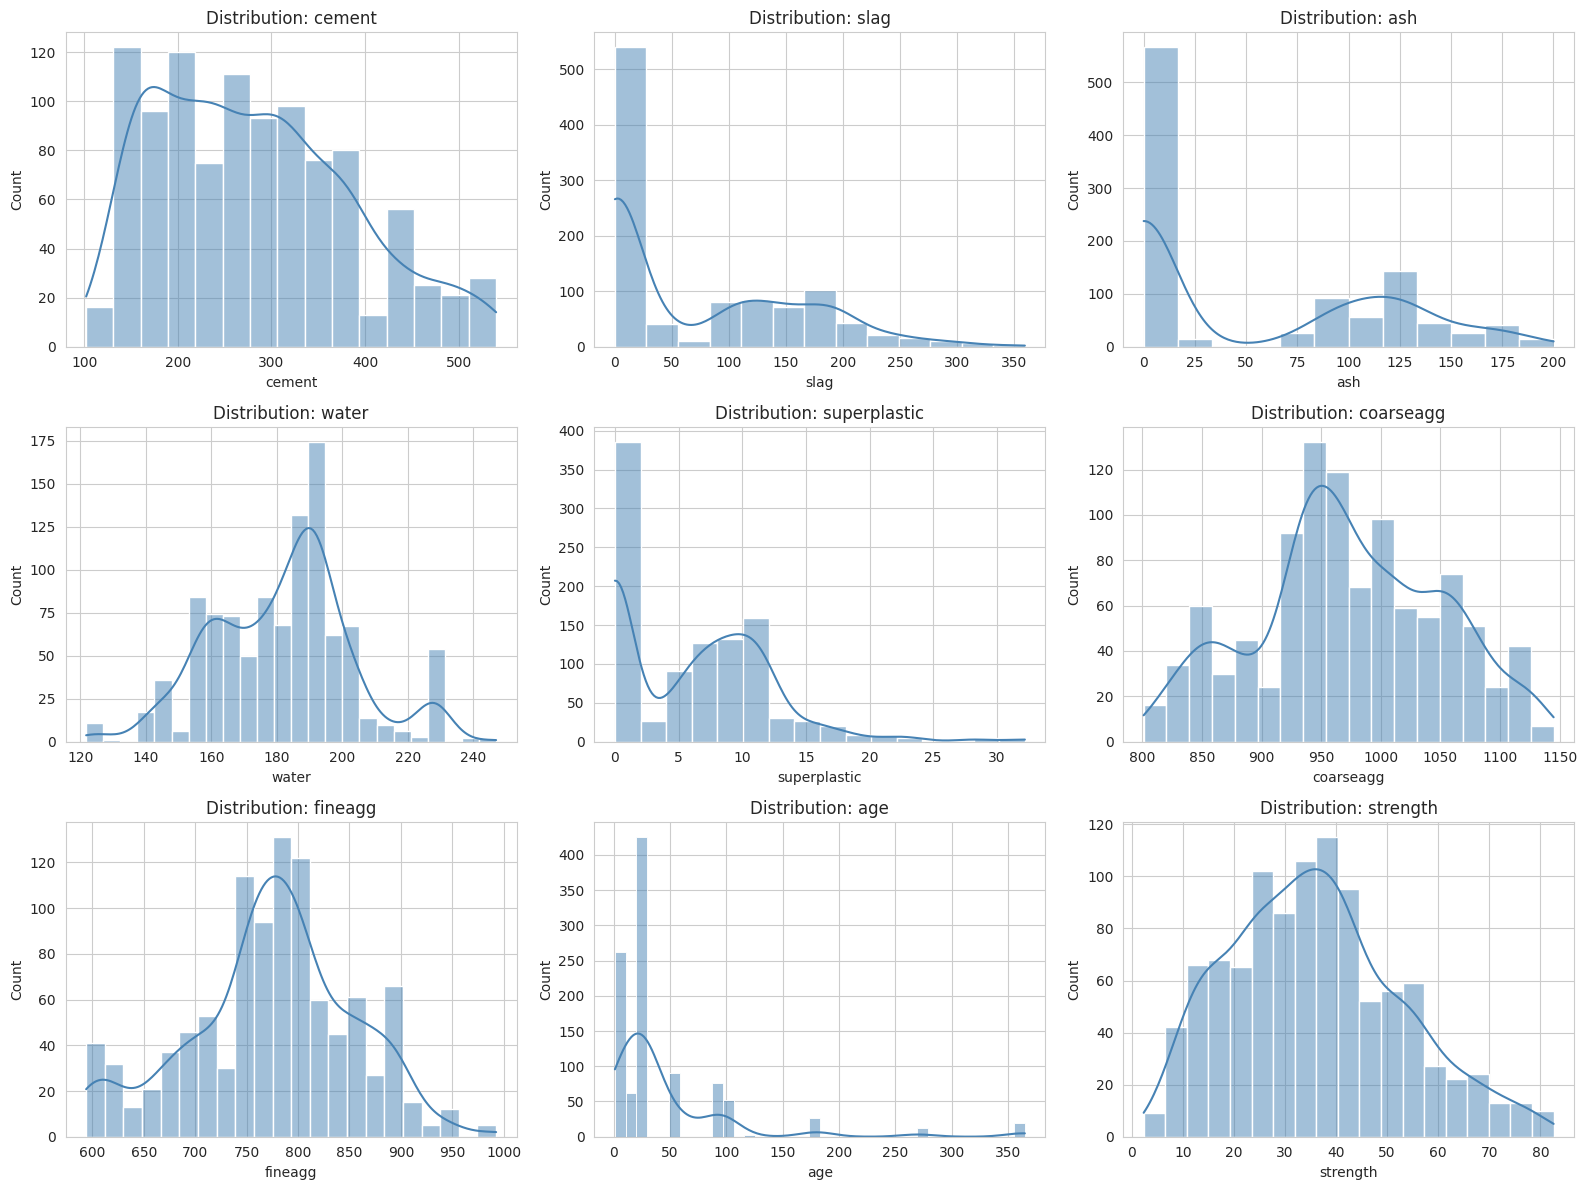

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(16,12))
for ax, col in zip(axes.flatten(), df.columns):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution: {col}")
plt.tight_layout()
plt.show()

### Outlier detection — boxplots + IQR method

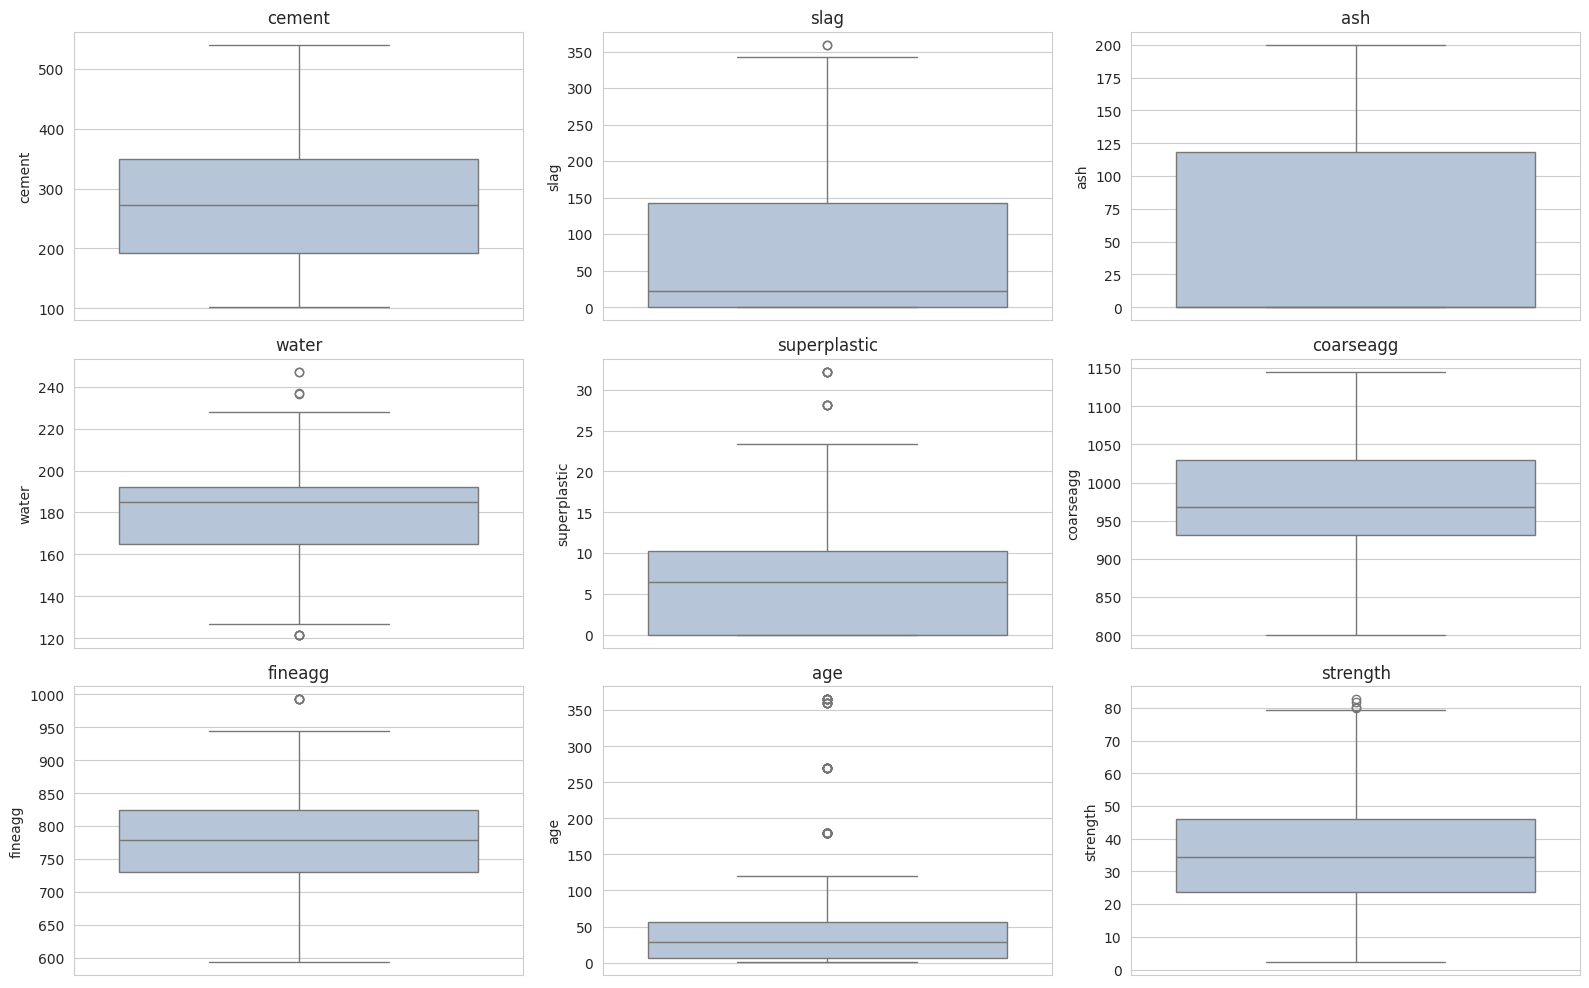

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(16,10))
for ax, col in zip(axes.flatten(), df.columns):
    sns.boxplot(y=df[col], ax=ax, color="lightsteelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [9]:
# Quantify outliers using the IQR method for each column
def iqr_outlier_summary(data):
    summary = []
    for col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
        summary.append({"feature": col, "lower_bound": round(lower,2), "upper_bound": round(upper,2),
                         "n_outliers": n_outliers, "pct_outliers": round(n_outliers/len(data)*100, 2)})
    return pd.DataFrame(summary)

outlier_summary = iqr_outlier_summary(df)
outlier_summary

,feature,lower_bound,upper_bound,n_outliers,pct_outliers
0,cement,-44.06,586.44,0,0.00
1,slag,-214.42,357.38,2,0.19
2,ash,-177.45,295.75,0,0.00
3,water,124.25,232.65,9,0.87
4,superplastic,-15.30,25.50,10,0.97
5,coarseagg,785.90,1175.50,0,0.00
6,fineagg,591.38,963.58,5,0.49
7,age,-66.50,129.50,59,5.73
8,strength,-9.93,79.77,4,0.39


### 1.2 Multivariate Analysis
Bivariate relationships between predictors, and between predictors and the target (`strength`).

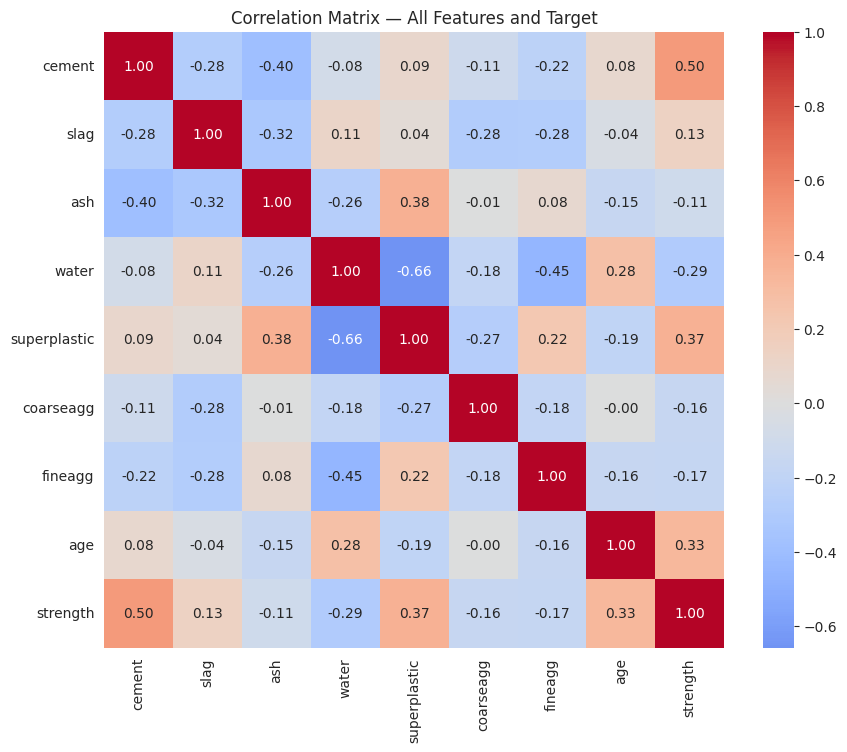

Correlation with target (strength), sorted:
strength        1.000000
cement          0.497832
superplastic    0.366079
age             0.328873
slag            0.134829
ash            -0.105755
coarseagg      -0.164935
fineagg        -0.167241
water          -0.289633
Name: strength, dtype: float64


In [10]:
# Correlation matrix
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — All Features and Target")
plt.show()

print("Correlation with target (strength), sorted:")
print(corr["strength"].sort_values(ascending=False))

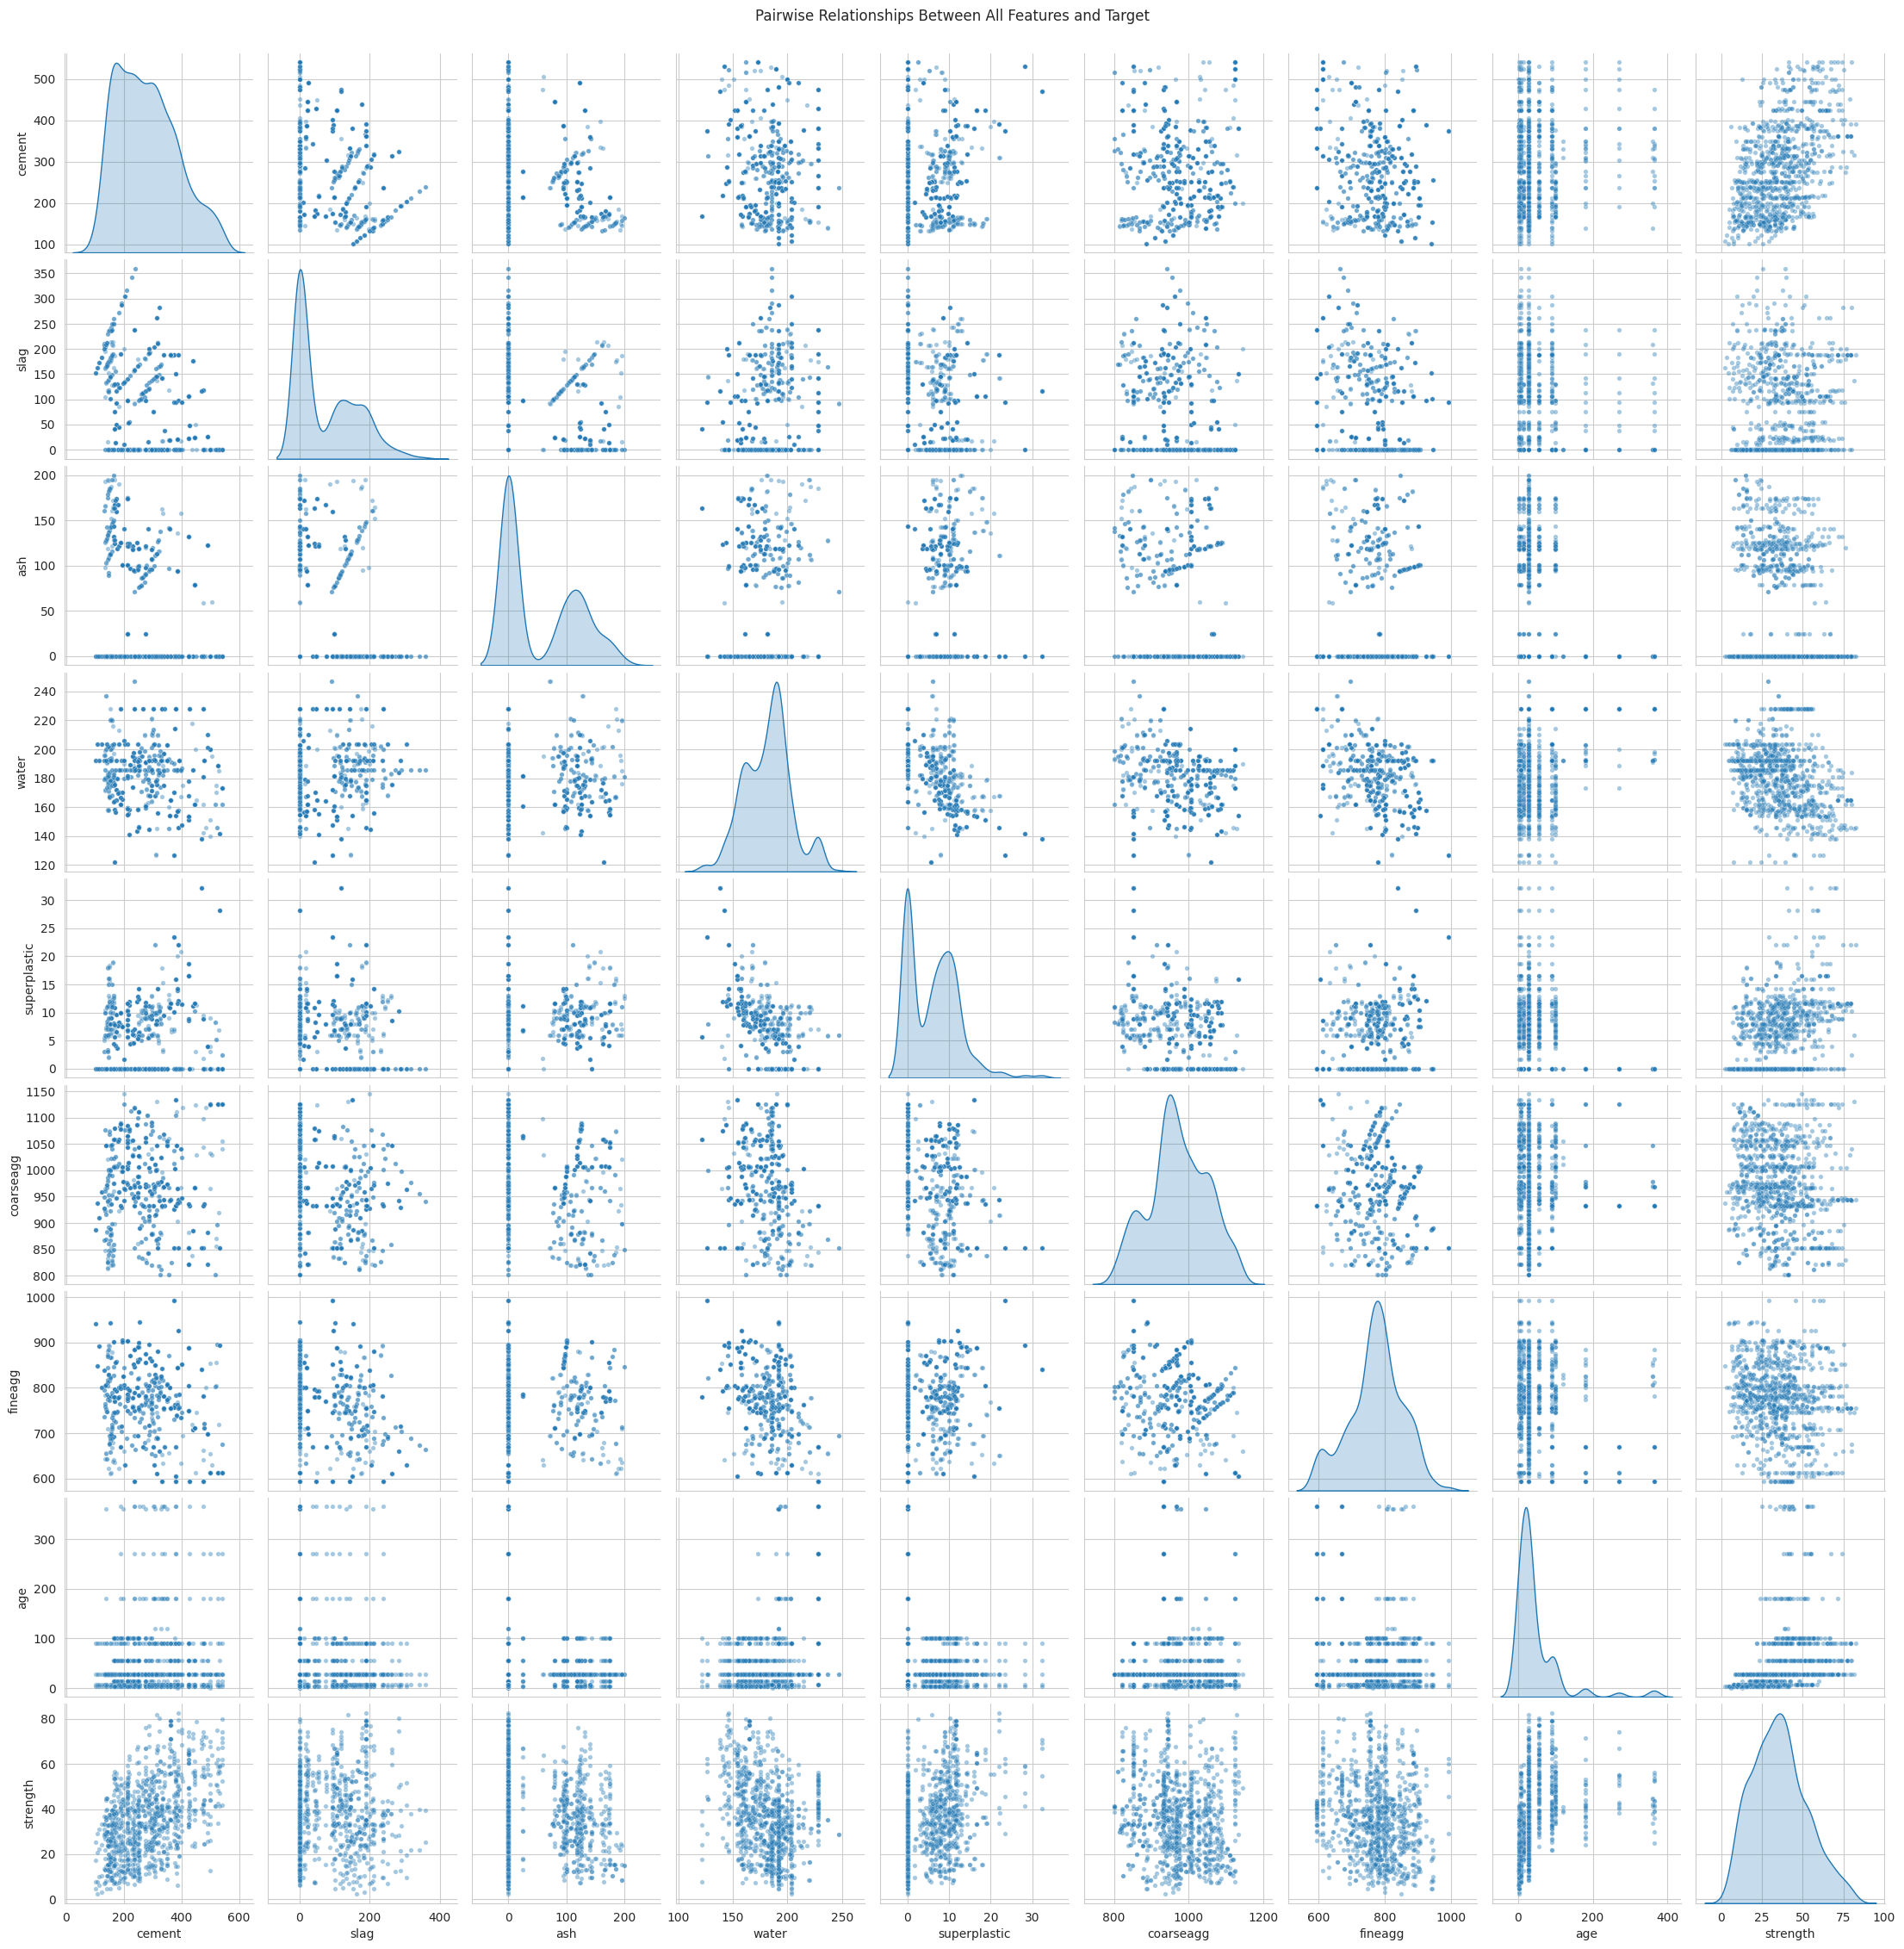

In [11]:
# Pair plot to visualize relationships and spot leverage points / clusters
sns.pairplot(df, diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15})
plt.suptitle("Pairwise Relationships Between All Features and Target", y=1.01)
plt.show()

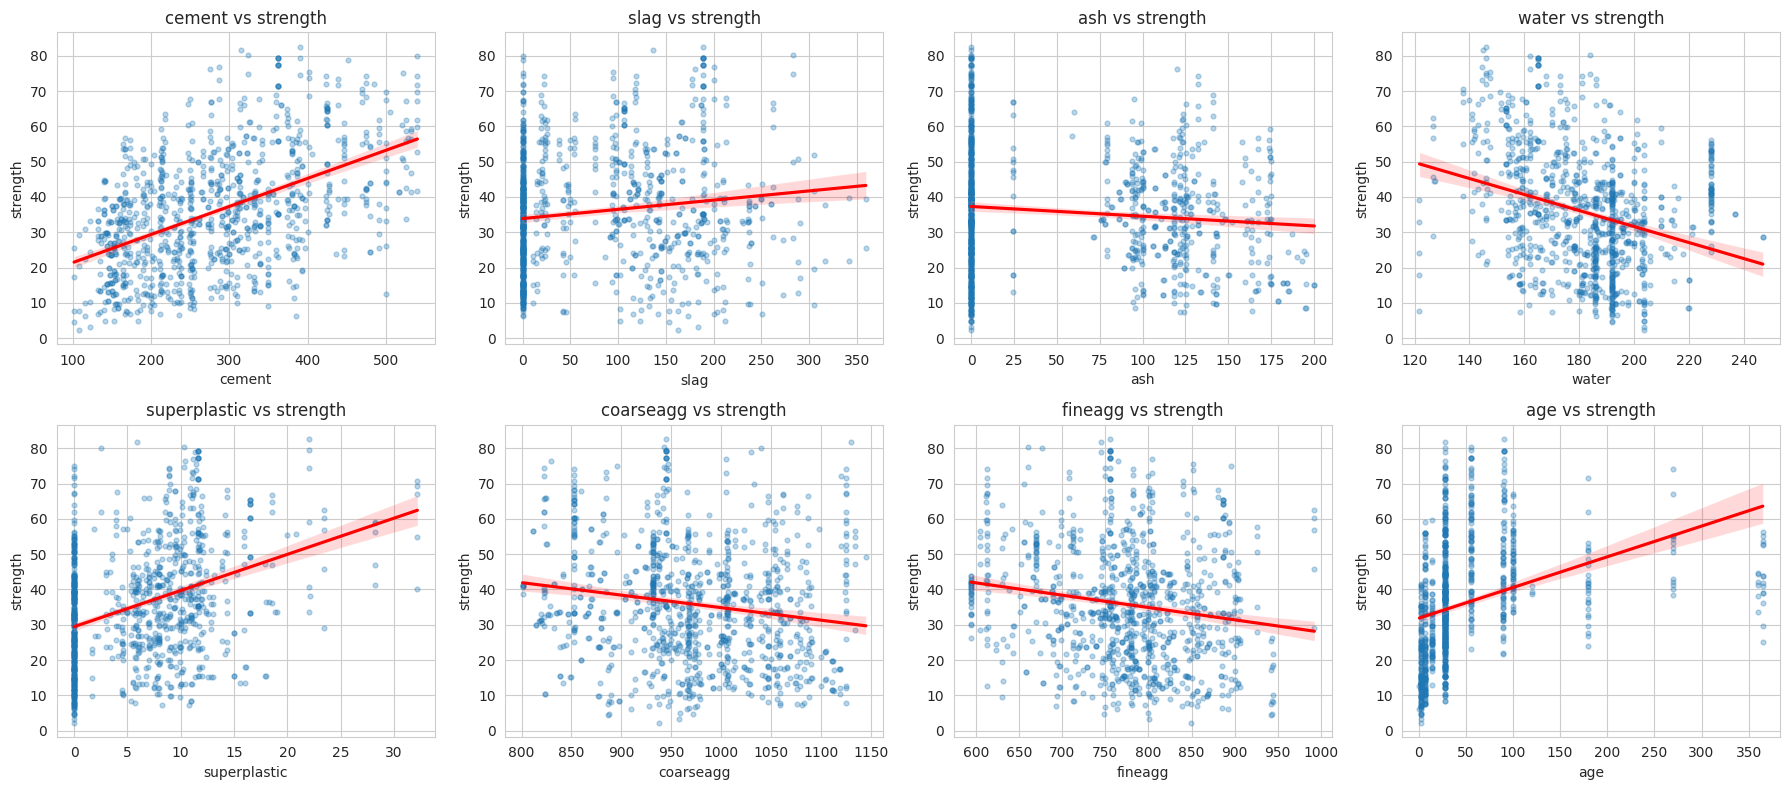

In [12]:
# Scatter plots: each predictor vs. target, with a regression trend line
predictors = [c for c in df.columns if c != "strength"]
fig, axes = plt.subplots(2, 4, figsize=(18,8))
for ax, col in zip(axes.flatten(), predictors):
    sns.regplot(x=df[col], y=df["strength"], ax=ax, scatter_kws={"alpha":0.3, "s":12}, line_kws={"color":"red"})
    ax.set_title(f"{col} vs strength")
plt.tight_layout()
plt.show()

### Leverage points — Cook's distance on a simple linear fit

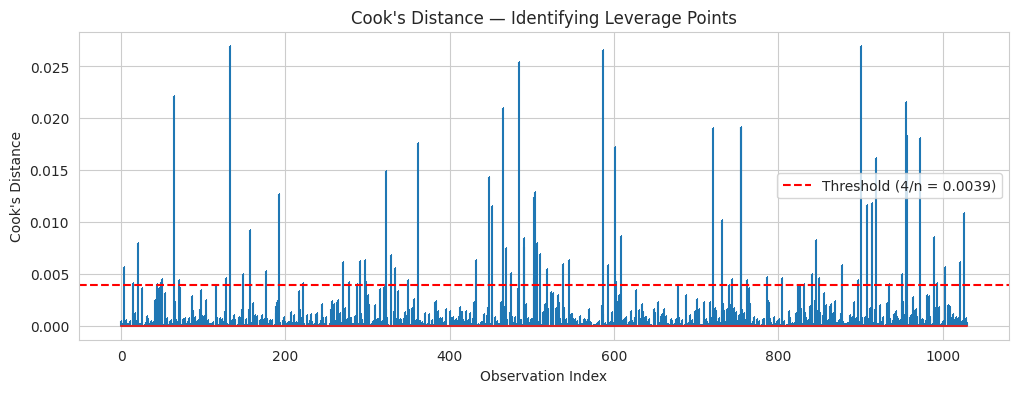

Number of potential leverage points (Cook's D > 4/n): 79 out of 1030


In [13]:
import statsmodels.api as sm

X_sm = sm.add_constant(df[predictors])
y_sm = df["strength"]
ols_model = sm.OLS(y_sm, X_sm).fit()

influence = ols_model.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(12,4))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
threshold = 4 / len(df)
plt.axhline(threshold, color="red", linestyle="--", label=f"Threshold (4/n = {threshold:.4f})")
plt.title("Cook's Distance — Identifying Leverage Points")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.show()

n_leverage_points = (cooks_d > threshold).sum()
print(f"Number of potential leverage points (Cook's D > 4/n): {n_leverage_points} out of {len(df)}")

### 1.3 Data Quality Strategy

Based on the analysis above:
- **Missing values:** this dataset has none in its cleaned CSV form, but the code above (`df.isnull().sum()`) is what you'd use to catch them — for a version with missing data, median imputation is a reasonable default for skewed numeric features like these.
- **Outliers:** flagged via the IQR method above. Given the domain (concrete mix proportions), extreme values are often legitimate unusual mix designs rather than data errors, so we retain them but will compare model performance with and without them below.
- **Duplicates:** checked above; drop any exact duplicate rows if present, since they would bias the model toward those specific mix designs.

In [14]:
# Optional: create an outlier-trimmed version of the data, to compare model performance later
def remove_iqr_outliers(data, cols, factor=1.5):
    mask = pd.Series(True, index=data.index)
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        mask &= data[col].between(lower, upper)
    return data[mask]

df_trimmed = remove_iqr_outliers(df, predictors)
print(f"Original rows: {len(df)}, After outlier trimming: {len(df_trimmed)} ({len(df)-len(df_trimmed)} removed)")

Original rows: 1030, After outlier trimming: 945 (85 removed)


---
## Deliverable 2 — Feature Engineering

### 2.1 Composite Features
Domain-informed ratios are common in concrete-strength modeling — e.g. the water-cement ratio is a well-known engineering driver of strength.

In [15]:
df_fe = df.copy()

# Water-cement ratio - a well-established concrete engineering metric
df_fe["water_cement_ratio"] = df_fe["water"] / df_fe["cement"]

# Total cementitious materials (cement + supplementary materials)
df_fe["total_binder"] = df_fe["cement"] + df_fe["slag"] + df_fe["ash"]

# Aggregate ratio
df_fe["agg_ratio"] = df_fe["coarseagg"] / df_fe["fineagg"]

# Binder-to-water ratio (inverse framing, sometimes more linear with strength)
df_fe["binder_water_ratio"] = df_fe["total_binder"] / df_fe["water"]

print("New composite features added:")
df_fe[["water_cement_ratio", "total_binder", "agg_ratio", "binder_water_ratio"]].describe()

New composite features added:


,water_cement_ratio,total_binder,agg_ratio,binder_water_ratio
count,1030.000000,1030.000000,1030.000000,1030.000000
mean,0.748266,409.252039,1.273752,2.298550
std,0.314005,92.780669,0.185670,0.648369
min,0.266893,200.000000,0.858453,1.111111
25%,0.533333,336.425000,1.121488,1.782275
50%,0.675349,391.300000,1.266055,2.118762
75%,0.935165,483.700000,1.358146,2.604739
max,1.882353,640.000000,1.874876,4.253991


In [16]:
# Check correlation of new composite features with strength
new_feature_corr = df_fe[["water_cement_ratio", "total_binder", "agg_ratio", "binder_water_ratio", "strength"]].corr()["strength"]
print("Correlation of composite features with strength:")
print(new_feature_corr.sort_values(ascending=False))

Correlation of composite features with strength:
strength              1.000000
binder_water_ratio    0.642016
total_binder          0.613184
agg_ratio             0.049028
water_cement_ratio   -0.500692
Name: strength, dtype: float64


### 2.2 Model Complexity — Is a Linear Relationship Enough?
Compare a simple linear fit vs. polynomial (degree 2) fits to see whether nonlinearity meaningfully helps, using cross-validated R².

In [17]:
X_base = df[predictors]
y = df["strength"]

degree_results = []
for degree in [1, 2, 3]:
    pipeline = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("linreg", LinearRegression())
    ])
    scores = cross_val_score(pipeline, X_base, y, cv=5, scoring="r2")
    degree_results.append({"degree": degree, "mean_r2": scores.mean(), "std_r2": scores.std(),
                            "n_features_generated": PolynomialFeatures(degree=degree).fit(X_base).n_output_features_})
    print(f"Degree {degree}: Mean CV R2 = {scores.mean():.4f} (+/- {scores.std():.4f})")

degree_results_df = pd.DataFrame(degree_results)
degree_results_df

Degree 1: Mean CV R2 = 0.6013 (+/- 0.0404)
Degree 2: Mean CV R2 = 0.7797 (+/- 0.0315)
Degree 3: Mean CV R2 = 0.8364 (+/- 0.0403)


,degree,mean_r2,std_r2,n_features_generated
0,1,0.601288,0.040388,9
1,2,0.779686,0.031522,45
2,3,0.836378,0.040337,165


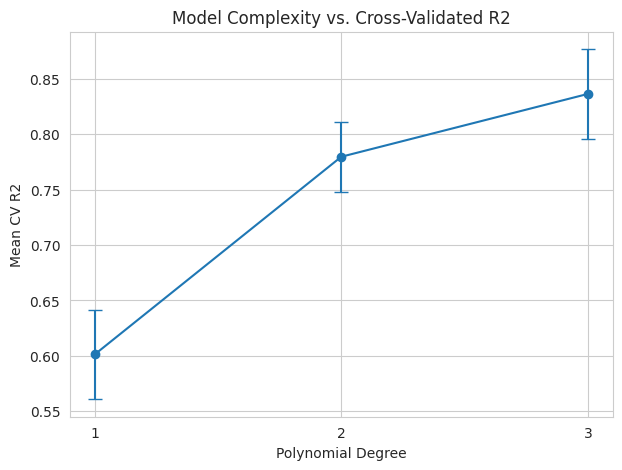

In [18]:
plt.figure(figsize=(7,5))
plt.errorbar(degree_results_df["degree"], degree_results_df["mean_r2"], yerr=degree_results_df["std_r2"], marker="o", capsize=5)
plt.title("Model Complexity vs. Cross-Validated R2")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean CV R2")
plt.xticks([1,2,3])
plt.show()

### 2.3 Exploring for Gaussian Mixtures
Check whether the data is better explained as a mix of underlying clusters (e.g. different concrete mix "families") rather than one homogeneous population.

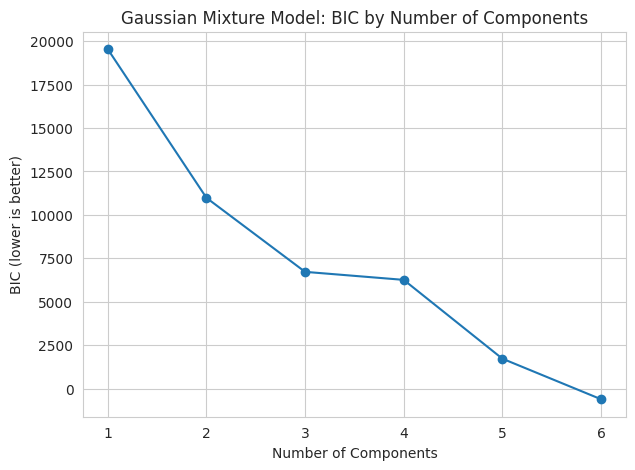

Best number of components by BIC: 6


In [19]:
scaler_gmm = StandardScaler()
X_scaled_gmm = scaler_gmm.fit_transform(df[predictors])

# Use BIC to select a reasonable number of Gaussian components
bic_scores = []
n_components_range = range(1, 7)
for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_scaled_gmm)
    bic_scores.append(gmm.bic(X_scaled_gmm))

plt.figure(figsize=(7,5))
plt.plot(list(n_components_range), bic_scores, marker="o")
plt.title("Gaussian Mixture Model: BIC by Number of Components")
plt.xlabel("Number of Components")
plt.ylabel("BIC (lower is better)")
plt.show()

best_n = list(n_components_range)[np.argmin(bic_scores)]
print(f"Best number of components by BIC: {best_n}")

In [20]:
# Fit GMM with the selected number of components and inspect cluster characteristics
gmm_final = GaussianMixture(n_components=best_n, random_state=42)
df_fe["gmm_cluster"] = gmm_final.fit_predict(X_scaled_gmm)

print("Cluster sizes:")
print(df_fe["gmm_cluster"].value_counts())

print("\nMean feature values by cluster (helps interpret what distinguishes each cluster):")
cluster_profile = df_fe.groupby("gmm_cluster")[predictors + ["strength"]].mean()
cluster_profile

Cluster sizes:
gmm_cluster
1    234
4    203
2    196
0    174
3    124
5     99
Name: count, dtype: int64

Mean feature values by cluster (helps interpret what distinguishes each cluster):


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
gmm_cluster,,,,,,,,,
0,234.548276,163.389655,0.000000,204.174713,0.000000,960.902299,724.349425,78.534483,30.001954
1,217.634615,16.485043,124.371795,170.083333,8.020513,1021.346154,813.155983,39.914530,33.648419
2,347.581633,0.000000,0.000000,190.988776,0.000000,1023.336224,779.291837,56.372449,28.435102
3,375.655645,149.041935,1.975806,160.533871,14.324194,931.558871,796.379839,36.822581,54.703548
4,221.463054,109.494581,87.118227,187.531527,9.133005,915.487685,755.974877,28.000000,32.946355
5,385.865657,31.482828,88.696970,164.439394,8.927273,949.326263,762.802020,27.555556,48.018182


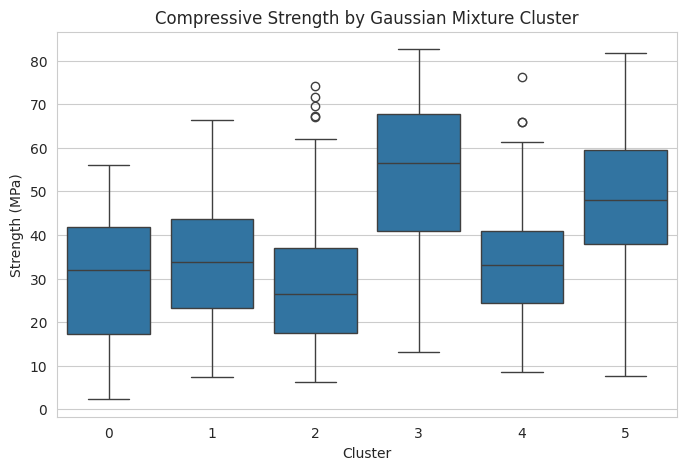

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x="gmm_cluster", y="strength", data=df_fe)
plt.title("Compressive Strength by Gaussian Mixture Cluster")
plt.xlabel("Cluster")
plt.ylabel("Strength (MPa)")
plt.show()

---
## Deliverable 3 — Model Building & Feature Importance

### 3.1 Train/Test Split (using the engineered feature set)

In [22]:
feature_cols = predictors + ["water_cement_ratio", "total_binder", "agg_ratio", "binder_water_ratio"]
X = df_fe[feature_cols]
y = df_fe["strength"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (824, 12) Test: (206, 12)


### 3.2 Baseline Models — Trying a Few Algorithm Families

In [23]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR (RBF)": SVR(kernel="rbf", C=10)
}

baseline_results = []
for name, model in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    baseline_results.append({"Model": name, "R2": r2, "MAE": mae, "RMSE": rmse,
                              "Accuracy (1-MAPE)": 1 - mape})

baseline_results_df = pd.DataFrame(baseline_results).sort_values("R2", ascending=False)
baseline_results_df

,Model,R2,MAE,RMSE,Accuracy (1-MAPE)
4,Gradient Boosting,0.919596,3.356058,4.796534,0.889854
3,Random Forest,0.917904,3.098187,4.846725,0.894237
5,SVR (RBF),0.803682,5.140042,7.494942,0.820187
1,Ridge Regression,0.614414,8.268616,10.503856,0.695596
0,Linear Regression,0.614312,8.261163,10.505246,0.695772
2,Lasso Regression,0.610130,8.359451,10.562043,0.692911


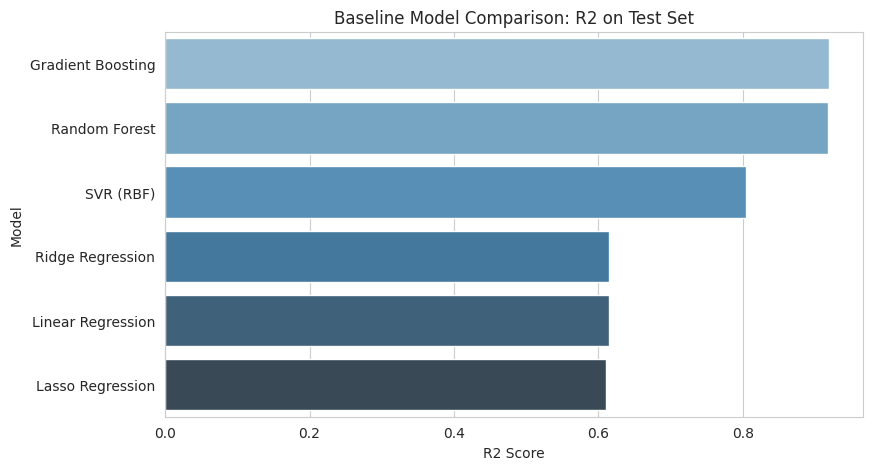

In [24]:
plt.figure(figsize=(9,5))
sns.barplot(x="R2", y="Model", data=baseline_results_df, hue="Model", legend=False, palette="Blues_d")
plt.title("Baseline Model Comparison: R2 on Test Set")
plt.xlabel("R2 Score")
plt.show()

### 3.3 Feature Importance — Multiple Methods
We compare feature importance from three different angles: (1) linear correlation, (2) tree-based Random Forest importance, and (3) permutation importance (model-agnostic).

In [25]:
# Method 1: simple correlation with target
corr_importance = X.copy()
corr_importance["strength"] = y
corr_importance = corr_importance.corr()["strength"].drop("strength").abs().sort_values(ascending=False)

print("Method 1 - Absolute Correlation with Target:")
print(corr_importance)

Method 1 - Absolute Correlation with Target:
binder_water_ratio    0.642016
total_binder          0.613184
water_cement_ratio    0.500692
cement                0.497832
superplastic          0.366079
age                   0.328873
water                 0.289633
fineagg               0.167241
coarseagg             0.164935
slag                  0.134829
ash                   0.105755
agg_ratio             0.049028
Name: strength, dtype: float64


In [26]:
# Method 2: Random Forest built-in feature importance
rf_for_importance = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_for_importance.fit(X_train, y_train)

rf_importance = pd.Series(rf_for_importance.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Method 2 - Random Forest Feature Importance:")
print(rf_importance)

Method 2 - Random Forest Feature Importance:
binder_water_ratio    0.395051
age                   0.361917
total_binder          0.075212
water_cement_ratio    0.050061
cement                0.032854
ash                   0.014280
slag                  0.013488
fineagg               0.013130
superplastic          0.012255
coarseagg             0.011790
water                 0.010364
agg_ratio             0.009598
dtype: float64


In [27]:
# Method 3: Permutation importance (model-agnostic, measures drop in performance when a feature is shuffled)
perm_result = permutation_importance(rf_for_importance, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1)
perm_importance = pd.Series(perm_result.importances_mean, index=feature_cols).sort_values(ascending=False)

print("Method 3 - Permutation Importance:")
print(perm_importance)

Method 3 - Permutation Importance:
age                   0.756217
binder_water_ratio    0.406601
total_binder          0.062900
water_cement_ratio    0.061769
cement                0.028099
ash                   0.012131
slag                  0.010109
superplastic          0.009884
fineagg               0.009183
coarseagg             0.006493
water                 0.005767
agg_ratio             0.004951
dtype: float64


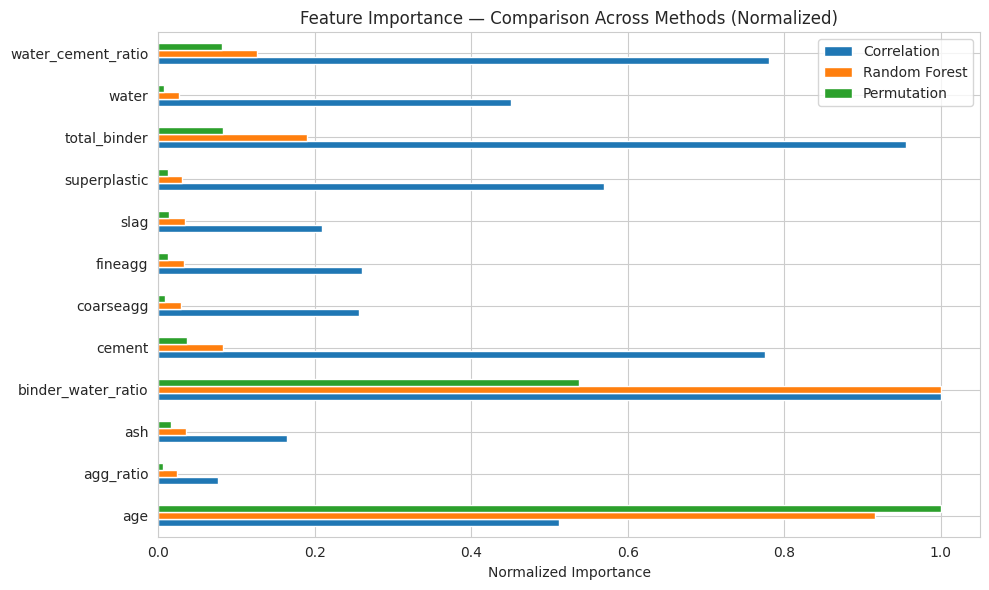

,Correlation,Random Forest,Permutation
age,0.328873,0.361917,0.756217
agg_ratio,0.049028,0.009598,0.004951
ash,0.105755,0.014280,0.012131
binder_water_ratio,0.642016,0.395051,0.406601
cement,0.497832,0.032854,0.028099
coarseagg,0.164935,0.011790,0.006493
fineagg,0.167241,0.013130,0.009183
slag,0.134829,0.013488,0.010109
superplastic,0.366079,0.012255,0.009884
total_binder,0.613184,0.075212,0.062900


In [28]:
# Side-by-side comparison of all three methods
importance_comparison = pd.DataFrame({
    "Correlation": corr_importance,
    "Random Forest": rf_importance,
    "Permutation": perm_importance
})

# Normalize each column to 0-1 so they're visually comparable despite different scales
importance_comparison_norm = importance_comparison / importance_comparison.max()

fig, ax = plt.subplots(figsize=(10,6))
importance_comparison_norm.plot(kind="barh", ax=ax)
plt.title("Feature Importance — Comparison Across Methods (Normalized)")
plt.xlabel("Normalized Importance")
plt.tight_layout()
plt.show()

importance_comparison

---
## Deliverable 4 — Model Tuning & Performance Evaluation

### 4.1 Hyperparameter Tuning
Based on the baseline comparison, Random Forest and Gradient Boosting are typically the strongest candidates for this dataset. We tune both with grid search and cross-validation to avoid overfitting.

In [29]:
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_pipe = Pipeline([("scaler", StandardScaler()), ("model", RandomForestRegressor(random_state=42, n_jobs=-1))])

rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=5, scoring="r2", n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print("Best Random Forest params:", rf_grid.best_params_)
print("Best CV R2:", rf_grid.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Random Forest params: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV R2: 0.9067349582334252


In [30]:
gb_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.8, 1.0]
}

gb_pipe = Pipeline([("scaler", StandardScaler()), ("model", GradientBoostingRegressor(random_state=42))])

gb_grid = GridSearchCV(gb_pipe, gb_param_grid, cv=5, scoring="r2", n_jobs=-1, verbose=1)
gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting params:", gb_grid.best_params_)
print("Best CV R2:", gb_grid.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Gradient Boosting params: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best CV R2: 0.9362328218253699


### 4.2 Overfitting / Underfitting Check
Compare train vs. test performance for the tuned models — a large gap signals overfitting.

In [31]:
def train_test_gap(model, X_train, y_train, X_test, y_test, name):
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))
    print(f"{name}: Train R2 = {train_r2:.4f} | Test R2 = {test_r2:.4f} | Gap = {train_r2 - test_r2:.4f}")
    return train_r2, test_r2

_ = train_test_gap(rf_grid.best_estimator_, X_train, y_train, X_test, y_test, "Tuned Random Forest")
_ = train_test_gap(gb_grid.best_estimator_, X_train, y_train, X_test, y_test, "Tuned Gradient Boosting")

Tuned Random Forest: Train R2 = 0.9854 | Test R2 = 0.9178 | Gap = 0.0676
Tuned Gradient Boosting: Train R2 = 0.9905 | Test R2 = 0.9331 | Gap = 0.0574


### 4.3 Final Model Selection & Test Set Performance

In [32]:
final_candidates = {
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned Gradient Boosting": gb_grid.best_estimator_
}

final_results = []
for name, model in final_candidates.items():
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    final_results.append({"Model": name, "R2": r2, "MAE": mae, "RMSE": rmse, "Accuracy (1-MAPE)": 1 - mape})

final_results_df = pd.DataFrame(final_results)
final_results_df

,Model,R2,MAE,RMSE,Accuracy (1-MAPE)
0,Tuned Random Forest,0.917767,3.098188,4.850790,0.894193
1,Tuned Gradient Boosting,0.933101,2.652290,4.375196,0.906405


Selected final model: Tuned Gradient Boosting


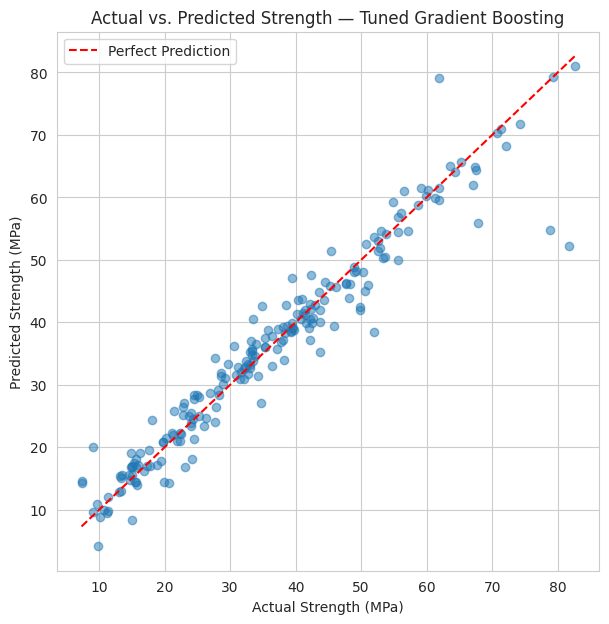

In [33]:
# Select the best model based on test R2
best_model_name = final_results_df.sort_values("R2", ascending=False).iloc[0]["Model"]
best_model = final_candidates[best_model_name]
print(f"Selected final model: {best_model_name}")

y_pred_final = best_model.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_final, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="Perfect Prediction")
plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title(f"Actual vs. Predicted Strength — {best_model_name}")
plt.legend()
plt.show()

### 4.4 Model Performance Range at 95% Confidence Level
Using repeated cross-validation to estimate a confidence interval on R2, rather than relying on a single train/test split.

10-Fold CV R2 scores: [0.8985 0.966  0.9504 0.9528 0.9691 0.9461 0.9093 0.9733 0.9721 0.9332]

Mean R2: 0.9471
95% Confidence Interval for R2: [0.9293, 0.9649]


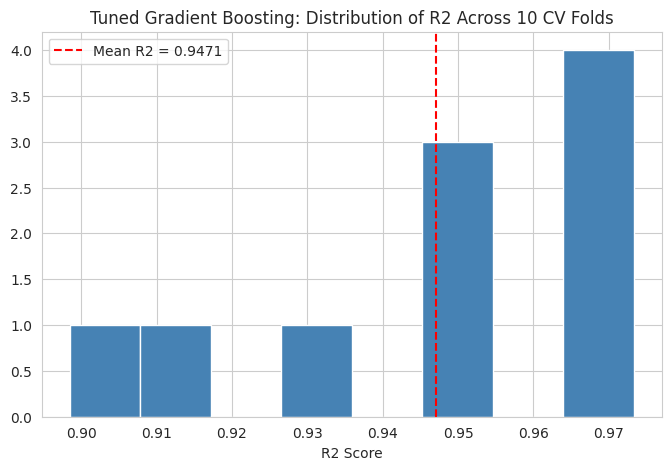

In [34]:
cv_scores = cross_val_score(best_model, X, y, cv=KFold(n_splits=10, shuffle=True, random_state=42), scoring="r2")

mean_r2 = cv_scores.mean()
std_r2 = cv_scores.std()
n = len(cv_scores)

# 95% confidence interval using the t-distribution (small sample of CV folds)
conf_interval = stats.t.interval(0.95, df=n-1, loc=mean_r2, scale=std_r2/np.sqrt(n))

print(f"10-Fold CV R2 scores: {np.round(cv_scores, 4)}")
print(f"\nMean R2: {mean_r2:.4f}")
print(f"95% Confidence Interval for R2: [{conf_interval[0]:.4f}, {conf_interval[1]:.4f}]")

plt.figure(figsize=(8,5))
plt.hist(cv_scores, bins=8, color="steelblue", edgecolor="white")
plt.axvline(mean_r2, color="red", linestyle="--", label=f"Mean R2 = {mean_r2:.4f}")
plt.title(f"{best_model_name}: Distribution of R2 Across 10 CV Folds")
plt.xlabel("R2 Score")
plt.legend()
plt.show()

In [35]:
# Prediction-level accuracy: percentage of predictions within a tolerance band of the true value
# This maps directly to the problem statement's 85%-95% accuracy target framing
def accuracy_within_tolerance(y_true, y_pred, tolerance_pct):
    pct_error = np.abs((y_true - y_pred) / y_true)
    within = (pct_error <= tolerance_pct).mean()
    return within

for tol in [0.05, 0.10, 0.15, 0.20]:
    acc = accuracy_within_tolerance(y_test.values, y_pred_final, tol)
    print(f"Predictions within {tol*100:.0f}% of actual strength: {acc*100:.1f}%")

Predictions within 5% of actual strength: 49.0%
Predictions within 10% of actual strength: 69.4%
Predictions within 15% of actual strength: 84.5%
Predictions within 20% of actual strength: 90.3%


---
## Summary

- **EDA** identified feature distributions, outliers, and correlations — `cement` and `age` (and their engineered ratio `water_cement_ratio`) showed the strongest relationships with strength, consistent with concrete engineering domain knowledge.
- **Feature engineering** added domain-informed composite features (water-cement ratio, total binder, aggregate ratio) and explored model complexity and Gaussian mixture structure in the data.
- **Model building** compared multiple algorithm families; tree-based ensemble methods (Random Forest, Gradient Boosting) outperformed linear models, indicating meaningful nonlinearity in how mix proportions and age relate to strength. Feature importance was cross-checked across three independent methods for robustness.
- **Model tuning** used grid search with cross-validation to avoid overfitting, and reported a 95% confidence interval for R2 using repeated k-fold cross-validation rather than a single train/test split, along with a tolerance-band accuracy metric mapped directly to the problem statement's 85%-95% accuracy target.